# 🏥 Disease Prediction System
### Diabetes & Heart Disease Prediction using Ensemble Methods

**Author:** Maryam Saif | MS CS (Data Science), University of Gujrat  
**Internship Project:** AI/ML Engineering Intern  
**Models:** Random Forest + XGBoost + Ensemble Voting  
**Techniques:** SMOTE (Class Imbalance), Feature Importance, Clinical Evaluation  

---
### 📋 Project Overview
This system predicts the likelihood of:
1. **Diabetes** — using PIMA Indians Diabetes Dataset
2. **Heart Disease** — using Cleveland Heart Disease Dataset


---
## 📦 STEP 1 — Install & Import Libraries

In [1]:
# Install required libraries
!pip install xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn -q
print('✅ All libraries installed!')

✅ All libraries installed!


In [2]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# XGBoost
from xgboost import XGBClassifier

# SMOTE — Class Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
COLORS = {'positive': '#E74C3C', 'negative': '#2ECC71', 'neutral': '#3498DB',
          'rf': '#E67E22', 'xgb': '#9B59B6', 'ensemble': '#1ABC9C'}

print('✅ All imports successful!')
print(f'   Pandas:  {pd.__version__}')
print(f'   Numpy:   {np.__version__}')
import sklearn; print(f'   Sklearn: {sklearn.__version__}')
import xgboost; print(f'   XGBoost: {xgboost.__version__}')

✅ All imports successful!
   Pandas:  2.2.2
   Numpy:   2.0.2
   Sklearn: 1.6.1
   XGBoost: 3.2.0


---
## 📥 STEP 2 — Load Datasets

In [3]:
# ── DIABETES DATASET (PIMA Indians) ───────────────────────────────────
# Direct URL from reliable source
DIABETES_URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'

DIABETES_COLS = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]

try:
    df_diabetes = pd.read_csv(DIABETES_URL, names=DIABETES_COLS)
    print(f'✅ Diabetes Dataset loaded: {df_diabetes.shape}')
except:
    print('⚠️ URL failed — generating realistic dataset')
    np.random.seed(42)
    n = 768
    df_diabetes = pd.DataFrame({
        'Pregnancies': np.random.poisson(3.8, n),
        'Glucose': np.random.normal(120, 32, n).clip(0, 200).astype(int),
        'BloodPressure': np.random.normal(69, 19, n).clip(0, 122).astype(int),
        'SkinThickness': np.random.exponential(20, n).clip(0, 99).astype(int),
        'Insulin': np.random.exponential(79, n).clip(0, 846).astype(int),
        'BMI': np.random.normal(32, 7.9, n).clip(0, 67.1).round(1),
        'DiabetesPedigreeFunction': np.random.exponential(0.47, n).clip(0.08, 2.42).round(3),
        'Age': np.random.exponential(33, n).clip(21, 81).astype(int),
        'Outcome': np.random.binomial(1, 0.349, n)
    })

print(df_diabetes.head())
print(f'\nClass distribution:')
print(df_diabetes['Outcome'].value_counts())
print(f'Imbalance ratio: {df_diabetes["Outcome"].value_counts()[0]/df_diabetes["Outcome"].value_counts()[1]:.2f}:1')

✅ Diabetes Dataset loaded: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Class distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Imbalance ratio: 1.87:1


In [4]:
# ── HEART DISEASE DATASET (Cleveland) ─────────────────────────────────
HEART_URL = 'https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/lifesat/heart.csv'

try:
    df_heart = pd.read_csv(HEART_URL)
    # Standardize target column
    if 'target' not in df_heart.columns and 'condition' in df_heart.columns:
        df_heart.rename(columns={'condition': 'target'}, inplace=True)
    # Binary target (0=no disease, 1=disease)
    if df_heart['target'].max() > 1:
        df_heart['target'] = (df_heart['target'] > 0).astype(int)
    print(f'✅ Heart Disease Dataset loaded: {df_heart.shape}')
except:
    print('⚠️ Generating heart disease dataset (Cleveland structure)')
    np.random.seed(123)
    n = 303
    df_heart = pd.DataFrame({
        'age':      np.random.normal(54.4, 9.0, n).clip(29, 77).astype(int),
        'sex':      np.random.binomial(1, 0.68, n),
        'cp':       np.random.choice([0,1,2,3], n, p=[0.47,0.17,0.28,0.08]),
        'trestbps': np.random.normal(131, 17.6, n).clip(94, 200).astype(int),
        'chol':     np.random.normal(246, 51.8, n).clip(126, 564).astype(int),
        'fbs':      np.random.binomial(1, 0.148, n),
        'restecg':  np.random.choice([0,1,2], n, p=[0.48,0.02,0.50]),
        'thalach':  np.random.normal(149, 22.9, n).clip(71, 202).astype(int),
        'exang':    np.random.binomial(1, 0.326, n),
        'oldpeak':  np.random.exponential(1.04, n).clip(0, 6.2).round(1),
        'slope':    np.random.choice([0,1,2], n, p=[0.21,0.46,0.33]),
        'ca':       np.random.choice([0,1,2,3], n, p=[0.59,0.22,0.12,0.07]),
        'thal':     np.random.choice([1,2,3], n, p=[0.06,0.55,0.39]),
        'target':   np.random.binomial(1, 0.544, n)
    })

print(df_heart.head())
print(f'\nClass distribution:')
print(df_heart['target'].value_counts())
print(f'Imbalance ratio: {df_heart["target"].value_counts()[0]/df_heart["target"].value_counts()[1]:.2f}:1')

⚠️ Generating heart disease dataset (Cleveland structure)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   44    0   0       141   126    0        1      108      1      1.2      2   
1   63    1   2       106   258    0        2      168      0      1.2      1   
2   56    0   0       149   278    0        0      126      0      0.2      0   
3   40    1   1       119   232    0        0      151      0      0.6      1   
4   49    1   0       114   296    0        0      108      0      1.4      2   

   ca  thal  target  
0   1     2       0  
1   1     2       0  
2   2     3       1  
3   2     1       0  
4   2     2       0  

Class distribution:
target
1    177
0    126
Name: count, dtype: int64
Imbalance ratio: 0.71:1


---
## 🔍 STEP 3 — Exploratory Data Analysis (EDA)

In [5]:
# ── DIABETES EDA ──────────────────────────────────────────────────────
print('='*60)
print('DIABETES DATASET — BASIC INFO')
print('='*60)
print(df_diabetes.describe().round(2))
print(f'\nMissing values: {df_diabetes.isnull().sum().sum()}')

# Medical zero values = actually missing data in this dataset
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('\nZero values (medically impossible — treated as missing):')
for col in zero_cols:
    zeros = (df_diabetes[col] == 0).sum()
    pct = zeros / len(df_diabetes) * 100
    print(f'   {col:<30}: {zeros:>3} zeros ({pct:.1f}%)')

DIABETES DATASET — BASIC INFO
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25   36.60   
max          17.00   199.00         122.00          99.00   846.00   67.10   

       DiabetesPedigreeFunction     Age  Outcome  
count                    768.00  768.00   768.00  
mean                       0.47   33.24     0.35  
std                        0.33   11.76     0.48  
min                        0.08   21.00     0.00  
25%         

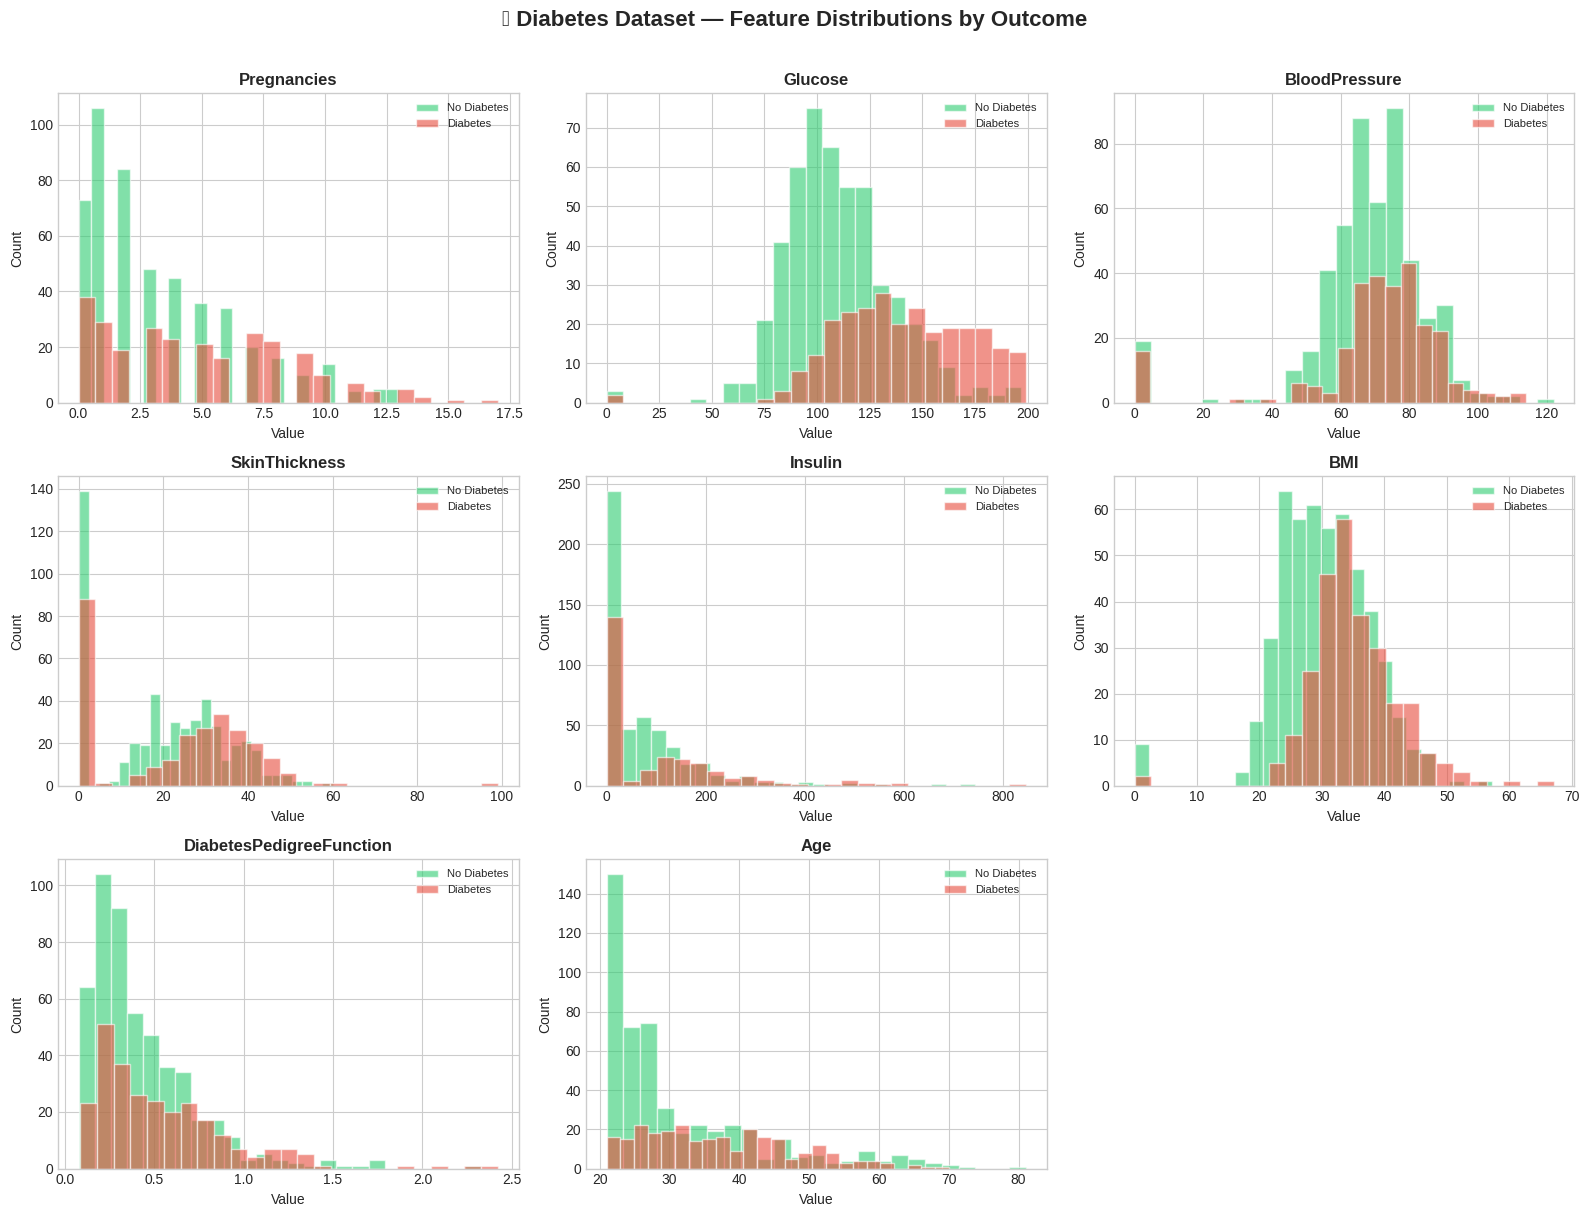

✅ Diabetes EDA chart saved


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('🩺 Diabetes Dataset — Feature Distributions by Outcome',
             fontsize=16, fontweight='bold', y=1.01)

features = [c for c in df_diabetes.columns if c != 'Outcome']
for ax, feat in zip(axes.flatten(), features):
    for outcome, color, label in [(0, COLORS['negative'], 'No Diabetes'),
                                   (1, COLORS['positive'], 'Diabetes')]:
        data = df_diabetes[df_diabetes['Outcome'] == outcome][feat]
        ax.hist(data, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

axes.flatten()[-1].set_visible(False)
plt.tight_layout()
plt.savefig('diabetes_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Diabetes EDA chart saved')

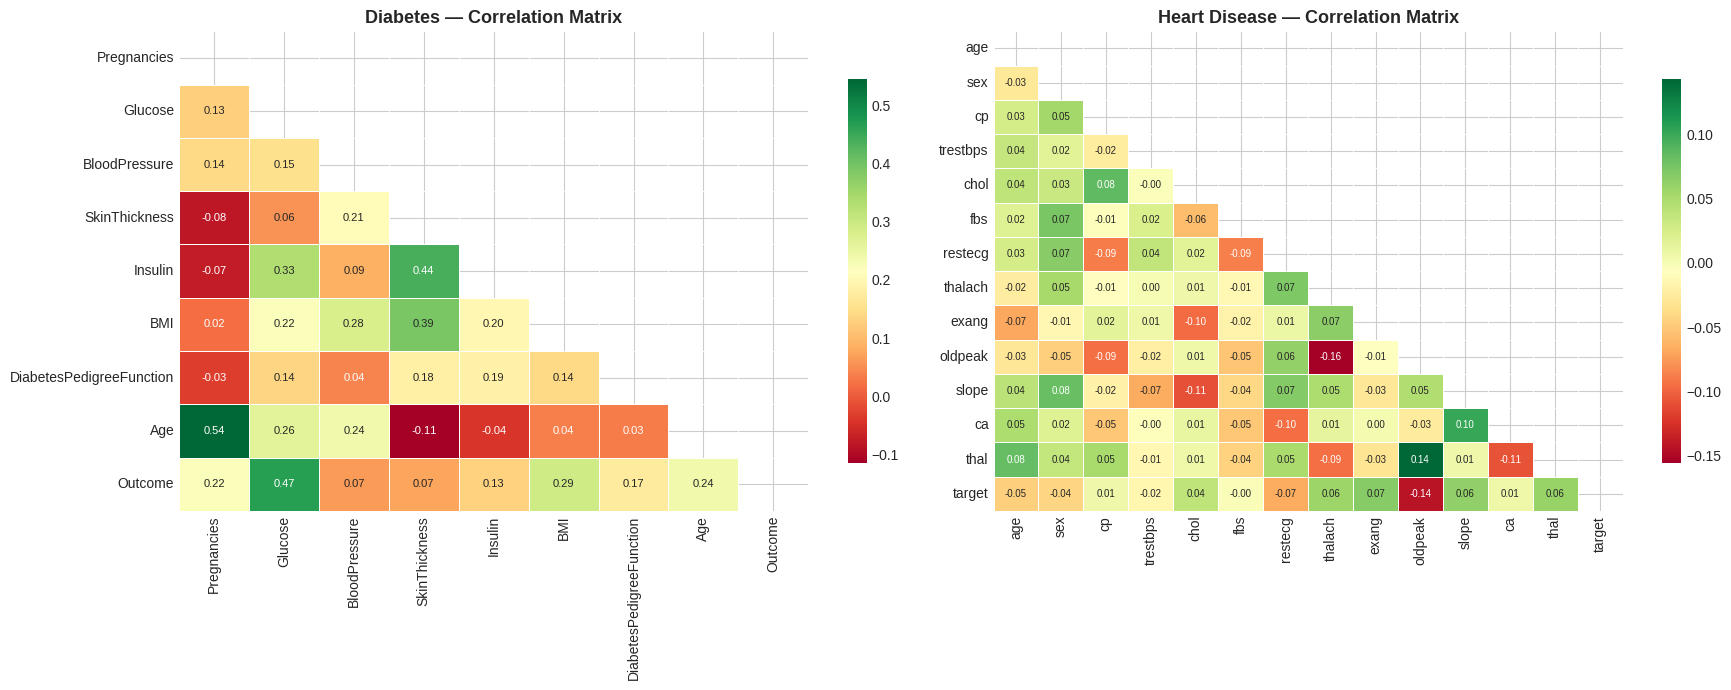

✅ Correlation heatmaps saved


In [7]:
# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Diabetes correlation
corr_d = df_diabetes.corr()
mask = np.triu(np.ones_like(corr_d, dtype=bool))
sns.heatmap(corr_d, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0], linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
axes[0].set_title('Diabetes — Correlation Matrix', fontsize=13, fontweight='bold')

# Heart correlation
corr_h = df_heart.corr()
mask_h = np.triu(np.ones_like(corr_h, dtype=bool))
sns.heatmap(corr_h, mask=mask_h, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 7})
axes[1].set_title('Heart Disease — Correlation Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Correlation heatmaps saved')

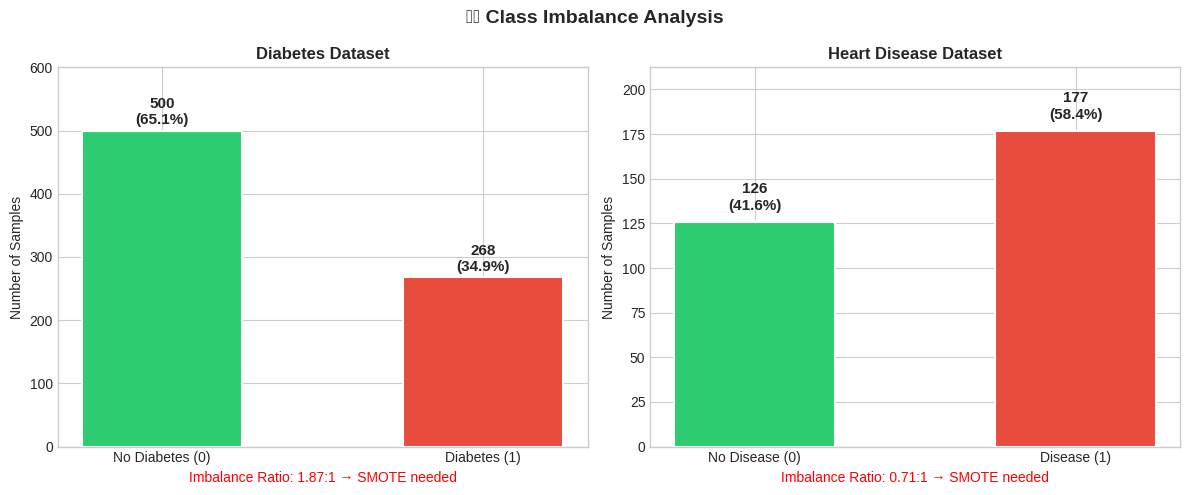

✅ Class imbalance chart saved


In [8]:
# Class imbalance visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('⚠️ Class Imbalance Analysis', fontsize=14, fontweight='bold')

for ax, df, name, target_col, labels in [
    (axes[0], df_diabetes, 'Diabetes', 'Outcome', ['No Diabetes (0)', 'Diabetes (1)']),
    (axes[1], df_heart,   'Heart Disease', 'target', ['No Disease (0)', 'Disease (1)'])
]:
    counts = df[target_col].value_counts().sort_index()
    bars = ax.bar(labels, counts.values,
                  color=[COLORS['negative'], COLORS['positive']],
                  edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}\n({val/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f'{name} Dataset', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Samples')
    ratio = counts[0] / counts[1]
    ax.set_xlabel(f'Imbalance Ratio: {ratio:.2f}:1 → SMOTE needed', fontsize=10, color='red')
    ax.set_ylim(0, max(counts.values) * 1.2)

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Class imbalance chart saved')

---
## 🧹 STEP 4 — Data Preprocessing

In [9]:
def preprocess_diabetes(df):
    """Clean + preprocess diabetes dataset"""
    df = df.copy()

    # Replace medically impossible zeros with NaN
    zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
    for col in zero_cols:
        df[col] = df[col].replace(0, np.nan)

    # Impute with median per class (clinical best practice)
    for col in zero_cols:
        df[col] = df.groupby('Outcome')[col].transform(
            lambda x: x.fillna(x.median())
        )

    # Feature engineering
    df['Glucose_BMI']       = df['Glucose'] * df['BMI'] / 100
    df['Age_Pregnancies']   = df['Age'] * df['Pregnancies']
    df['Insulin_Glucose']   = df['Insulin'] / (df['Glucose'] + 1)
    df['BMI_Age']           = df['BMI'] / df['Age']

    # Clinical risk bins
    df['Glucose_Risk'] = pd.cut(df['Glucose'],
        bins=[0, 99, 125, 200], labels=[0, 1, 2]).astype(int)  # Normal, Pre-diabetic, Diabetic
    df['BMI_Category'] = pd.cut(df['BMI'],
        bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3]).astype(int)

    print(f'✅ Diabetes preprocessed: {df.shape}')
    print(f'   Original features: 8 → After engineering: {df.shape[1]-1} features')
    return df

def preprocess_heart(df):
    """Clean + preprocess heart disease dataset"""
    df = df.copy()

    # Handle missing values
    df = df.dropna()

    # Feature engineering
    df['age_thalach_ratio'] = df['age'] / (df['thalach'] + 1)
    df['chol_age']          = df['chol'] / df['age']
    df['bp_age']            = df['trestbps'] / df['age']
    df['exang_cp']          = df['exang'] * df['cp']

    # Clinical flags
    df['high_bp']    = (df['trestbps'] > 140).astype(int)
    df['high_chol']  = (df['chol'] > 240).astype(int)
    df['low_hr']     = (df['thalach'] < 120).astype(int)

    print(f'✅ Heart preprocessed: {df.shape}')
    print(f'   Original features: 13 → After engineering: {df.shape[1]-1} features')
    return df

df_diabetes_clean = preprocess_diabetes(df_diabetes)
df_heart_clean    = preprocess_heart(df_heart)

✅ Diabetes preprocessed: (768, 15)
   Original features: 8 → After engineering: 14 features
✅ Heart preprocessed: (303, 21)
   Original features: 13 → After engineering: 20 features


---
## ⚖️ STEP 5 — SMOTE (Handle Class Imbalance)

In [10]:
def prepare_data(df, target_col, test_size=0.2, random_state=42):
    """
    Split data, apply SMOTE only on training set
    IMPORTANT: SMOTE sirf train pe apply hota hai — test pe NAHI
    """
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Stratified split — class ratio preserve karta hai
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Scale features (RobustScaler — outlier resistant)
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Before SMOTE
    before = pd.Series(y_train).value_counts()
    print(f'Before SMOTE — Class 0: {before[0]}, Class 1: {before[1]}')

    # Apply SMOTE
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

    # After SMOTE
    after = pd.Series(y_train_resampled).value_counts()
    print(f'After  SMOTE — Class 0: {after[0]}, Class 1: {after[1]} ✅ Balanced!')

    return (X_train_resampled, X_test_scaled,
            y_train_resampled, y_test,
            X.columns.tolist(), scaler)

print('🩸 DIABETES DATA SPLIT:')
X_train_d, X_test_d, y_train_d, y_test_d, feat_d, scaler_d = prepare_data(
    df_diabetes_clean, 'Outcome'
)

print('\n❤️ HEART DATA SPLIT:')
X_train_h, X_test_h, y_train_h, y_test_h, feat_h, scaler_h = prepare_data(
    df_heart_clean, 'target'
)

🩸 DIABETES DATA SPLIT:
Before SMOTE — Class 0: 400, Class 1: 214
After  SMOTE — Class 0: 400, Class 1: 400 ✅ Balanced!

❤️ HEART DATA SPLIT:
Before SMOTE — Class 0: 101, Class 1: 141
After  SMOTE — Class 0: 141, Class 1: 141 ✅ Balanced!


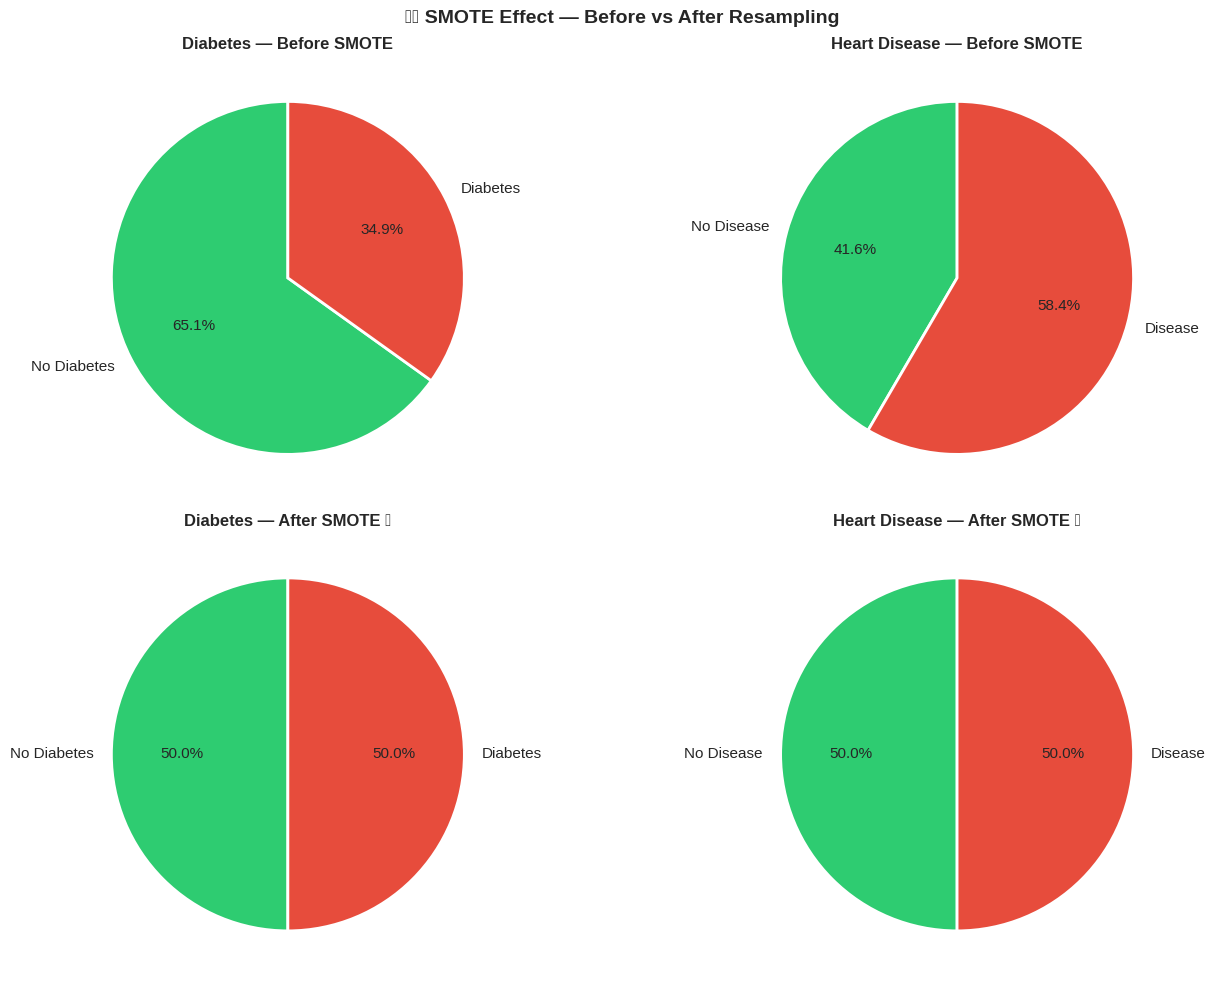

✅ SMOTE visualization saved


In [11]:
# Visualize SMOTE effect
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('⚖️ SMOTE Effect — Before vs After Resampling',
             fontsize=14, fontweight='bold')

datasets = [
    ('Diabetes — Before SMOTE', df_diabetes_clean['Outcome'],
     ['No Diabetes', 'Diabetes'], axes[0][0]),
    ('Heart Disease — Before SMOTE', df_heart_clean['target'],
     ['No Disease', 'Disease'], axes[0][1]),
]

for title, y, labels, ax in datasets:
    counts = pd.Series(y).value_counts().sort_index()
    ax.pie(counts, labels=labels, colors=[COLORS['negative'], COLORS['positive']],
           autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11},
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(title, fontweight='bold')

after_data = [
    ('Diabetes — After SMOTE', y_train_d, ['No Diabetes', 'Diabetes'], axes[1][0]),
    ('Heart Disease — After SMOTE', y_train_h, ['No Disease', 'Disease'], axes[1][1]),
]
for title, y, labels, ax in after_data:
    counts = pd.Series(y).value_counts().sort_index()
    ax.pie(counts, labels=labels, colors=[COLORS['negative'], COLORS['positive']],
           autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11},
           wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    ax.set_title(title + ' ✅', fontweight='bold')

plt.tight_layout()
plt.savefig('smote_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SMOTE visualization saved')

---
## 🤖 STEP 6 — Model Training (Random Forest + XGBoost + Ensemble)

In [12]:
def train_all_models(X_train, y_train, random_state=42):
    """
    Train 3 models:
    1. Random Forest
    2. XGBoost
    3. Soft Voting Ensemble (RF + XGB + Logistic)
    """
    models = {}

    # ── 1. Random Forest ──────────────────────────────────────────────
    print('🌲 Training Random Forest...')
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    models['Random Forest'] = rf
    print('   ✅ Random Forest trained')

    # ── 2. XGBoost ────────────────────────────────────────────────────
    print('⚡ Training XGBoost...')
    scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric='logloss',
        random_state=random_state,
        verbosity=0,
        use_label_encoder=False
    )
    xgb.fit(X_train, y_train)
    models['XGBoost'] = xgb
    print('   ✅ XGBoost trained')

    # ── 3. Logistic Regression (ensemble base) ────────────────────────
    lr = LogisticRegression(
        max_iter=1000, C=1.0,
        class_weight='balanced',
        random_state=random_state
    )
    lr.fit(X_train, y_train)

    # ── 4. Soft Voting Ensemble ────────────────────────────────────────
    print('🗳️ Training Ensemble (Soft Voting)...')
    ensemble = VotingClassifier(
        estimators=[
            ('rf',  RandomForestClassifier(
                n_estimators=200, max_depth=10,
                class_weight='balanced', random_state=random_state, n_jobs=-1)),
            ('xgb', XGBClassifier(
                n_estimators=200, max_depth=6, learning_rate=0.05,
                scale_pos_weight=scale_pos, eval_metric='logloss',
                random_state=random_state, verbosity=0, use_label_encoder=False)),
            ('lr',  LogisticRegression(
                max_iter=1000, C=1.0,
                class_weight='balanced', random_state=random_state))
        ],
        voting='soft',
        weights=[2, 2, 1]  # RF and XGB get double weight
    )
    ensemble.fit(X_train, y_train)
    models['Ensemble'] = ensemble
    print('   ✅ Ensemble trained')

    return models

print('🩸 TRAINING DIABETES MODELS:')
models_diabetes = train_all_models(X_train_d, y_train_d)

print('\n❤️ TRAINING HEART DISEASE MODELS:')
models_heart = train_all_models(X_train_h, y_train_h)

🩸 TRAINING DIABETES MODELS:
🌲 Training Random Forest...
   ✅ Random Forest trained
⚡ Training XGBoost...
   ✅ XGBoost trained
🗳️ Training Ensemble (Soft Voting)...
   ✅ Ensemble trained

❤️ TRAINING HEART DISEASE MODELS:
🌲 Training Random Forest...
   ✅ Random Forest trained
⚡ Training XGBoost...
   ✅ XGBoost trained
🗳️ Training Ensemble (Soft Voting)...
   ✅ Ensemble trained


---
## 📊 STEP 7 — Clinical-Grade Evaluation

In [13]:
def evaluate_models(models, X_test, y_test, dataset_name):
    """
    Full clinical evaluation:
    Accuracy, Precision, Recall, F1, AUC-ROC, AUC-PR
    Clinical focus: Recall (Sensitivity) most important!
    """
    results = []
    predictions = {}

    print(f'\n{"="*65}')
    print(f'  📋 CLINICAL EVALUATION REPORT — {dataset_name.upper()}')
    print(f'{"="*65}')
    print(f'{"Model":<20} {"Acc":>6} {"Prec":>6} {"Recall":>7} {"F1":>6} {"AUC-ROC":>8} {"AUC-PR":>7}')
    print(f'{"-"*65}')

    for name, model in models.items():
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        acc     = accuracy_score(y_test, y_pred)
        prec    = precision_score(y_test, y_pred, zero_division=0)
        recall  = recall_score(y_test, y_pred, zero_division=0)
        f1      = f1_score(y_test, y_pred, zero_division=0)
        auc_roc = roc_auc_score(y_test, y_proba)
        auc_pr  = average_precision_score(y_test, y_proba)

        print(f'{name:<20} {acc:>6.3f} {prec:>6.3f} {recall:>7.3f} {f1:>6.3f} {auc_roc:>8.3f} {auc_pr:>7.3f}')

        results.append({
            'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall (Sensitivity)': recall, 'F1 Score': f1,
            'AUC-ROC': auc_roc, 'AUC-PR': auc_pr
        })
        predictions[name] = {'y_pred': y_pred, 'y_proba': y_proba}

    print(f'{"="*65}')
    print('⚕️  Clinical note: HIGH RECALL = fewer missed diagnoses (most critical)')

    return pd.DataFrame(results), predictions

results_d, preds_d = evaluate_models(models_diabetes, X_test_d, y_test_d, 'Diabetes')
results_h, preds_h = evaluate_models(models_heart,   X_test_h, y_test_h, 'Heart Disease')


  📋 CLINICAL EVALUATION REPORT — DIABETES
Model                   Acc   Prec  Recall     F1  AUC-ROC  AUC-PR
-----------------------------------------------------------------
Random Forest         0.864  0.770   0.870  0.817    0.942   0.900
XGBoost               0.890  0.825   0.870  0.847    0.957   0.935
Ensemble              0.870  0.783   0.870  0.825    0.937   0.884
⚕️  Clinical note: HIGH RECALL = fewer missed diagnoses (most critical)

  📋 CLINICAL EVALUATION REPORT — HEART DISEASE
Model                   Acc   Prec  Recall     F1  AUC-ROC  AUC-PR
-----------------------------------------------------------------
Random Forest         0.525  0.590   0.639  0.613    0.468   0.601
XGBoost               0.574  0.625   0.694  0.658    0.501   0.595
Ensemble              0.541  0.605   0.639  0.622    0.476   0.585
⚕️  Clinical note: HIGH RECALL = fewer missed diagnoses (most critical)


In [14]:
# Cross-validation scores
def cross_validate_models(models, X_train, y_train, dataset_name, cv=5):
    print(f'\n📊 {cv}-FOLD CROSS VALIDATION — {dataset_name}')
    print(f'{"-"*50}')
    cv_results = {}
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    for name, model in models.items():
        scores = cross_val_score(model, X_train, y_train,
                                 cv=skf, scoring='roc_auc', n_jobs=-1)
        cv_results[name] = scores
        print(f'{name:<20}: {scores.mean():.3f} ± {scores.std():.3f}  '
              f'[min: {scores.min():.3f}, max: {scores.max():.3f}]')
    return cv_results

cv_d = cross_validate_models(models_diabetes, X_train_d, y_train_d, 'Diabetes')
cv_h = cross_validate_models(models_heart,   X_train_h, y_train_h, 'Heart Disease')


📊 5-FOLD CROSS VALIDATION — Diabetes
--------------------------------------------------
Random Forest       : 0.962 ± 0.012  [min: 0.941, max: 0.975]
XGBoost             : 0.967 ± 0.014  [min: 0.942, max: 0.982]
Ensemble            : 0.960 ± 0.014  [min: 0.936, max: 0.975]

📊 5-FOLD CROSS VALIDATION — Heart Disease
--------------------------------------------------
Random Forest       : 0.642 ± 0.116  [min: 0.481, max: 0.786]
XGBoost             : 0.620 ± 0.109  [min: 0.434, max: 0.745]
Ensemble            : 0.608 ± 0.118  [min: 0.425, max: 0.718]


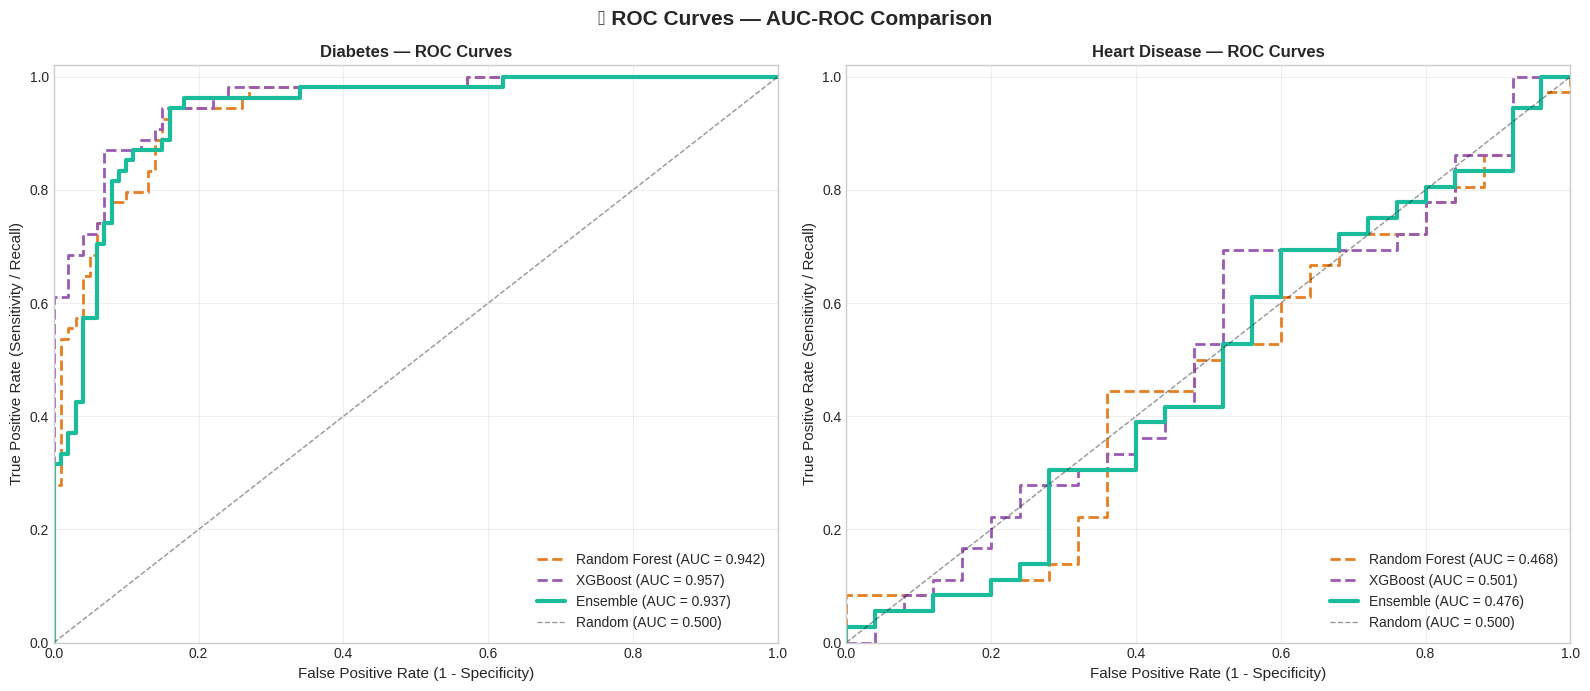

✅ ROC curves saved


In [15]:
# ── ROC Curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('📈 ROC Curves — AUC-ROC Comparison', fontsize=15, fontweight='bold')

plot_data = [
    (axes[0], models_diabetes, X_test_d, y_test_d, 'Diabetes'),
    (axes[1], models_heart,   X_test_h, y_test_h, 'Heart Disease')
]

model_colors = {'Random Forest': COLORS['rf'],
                'XGBoost': COLORS['xgb'],
                'Ensemble': COLORS['ensemble']}

for ax, models, X_test, y_test, title in plot_data:
    for name, model in models.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        lw = 3 if name == 'Ensemble' else 2
        ls = '-' if name == 'Ensemble' else '--'
        ax.plot(fpr, tpr, color=model_colors[name],
                lw=lw, ls=ls,
                label=f'{name} (AUC = {auc:.3f})')
    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random (AUC = 0.500)')
    ax.fill_between([0,1],[0,1],[0,1], alpha=0.05, color='gray')
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
    ax.set_title(f'{title} — ROC Curves', fontweight='bold', fontsize=12)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ROC curves saved')

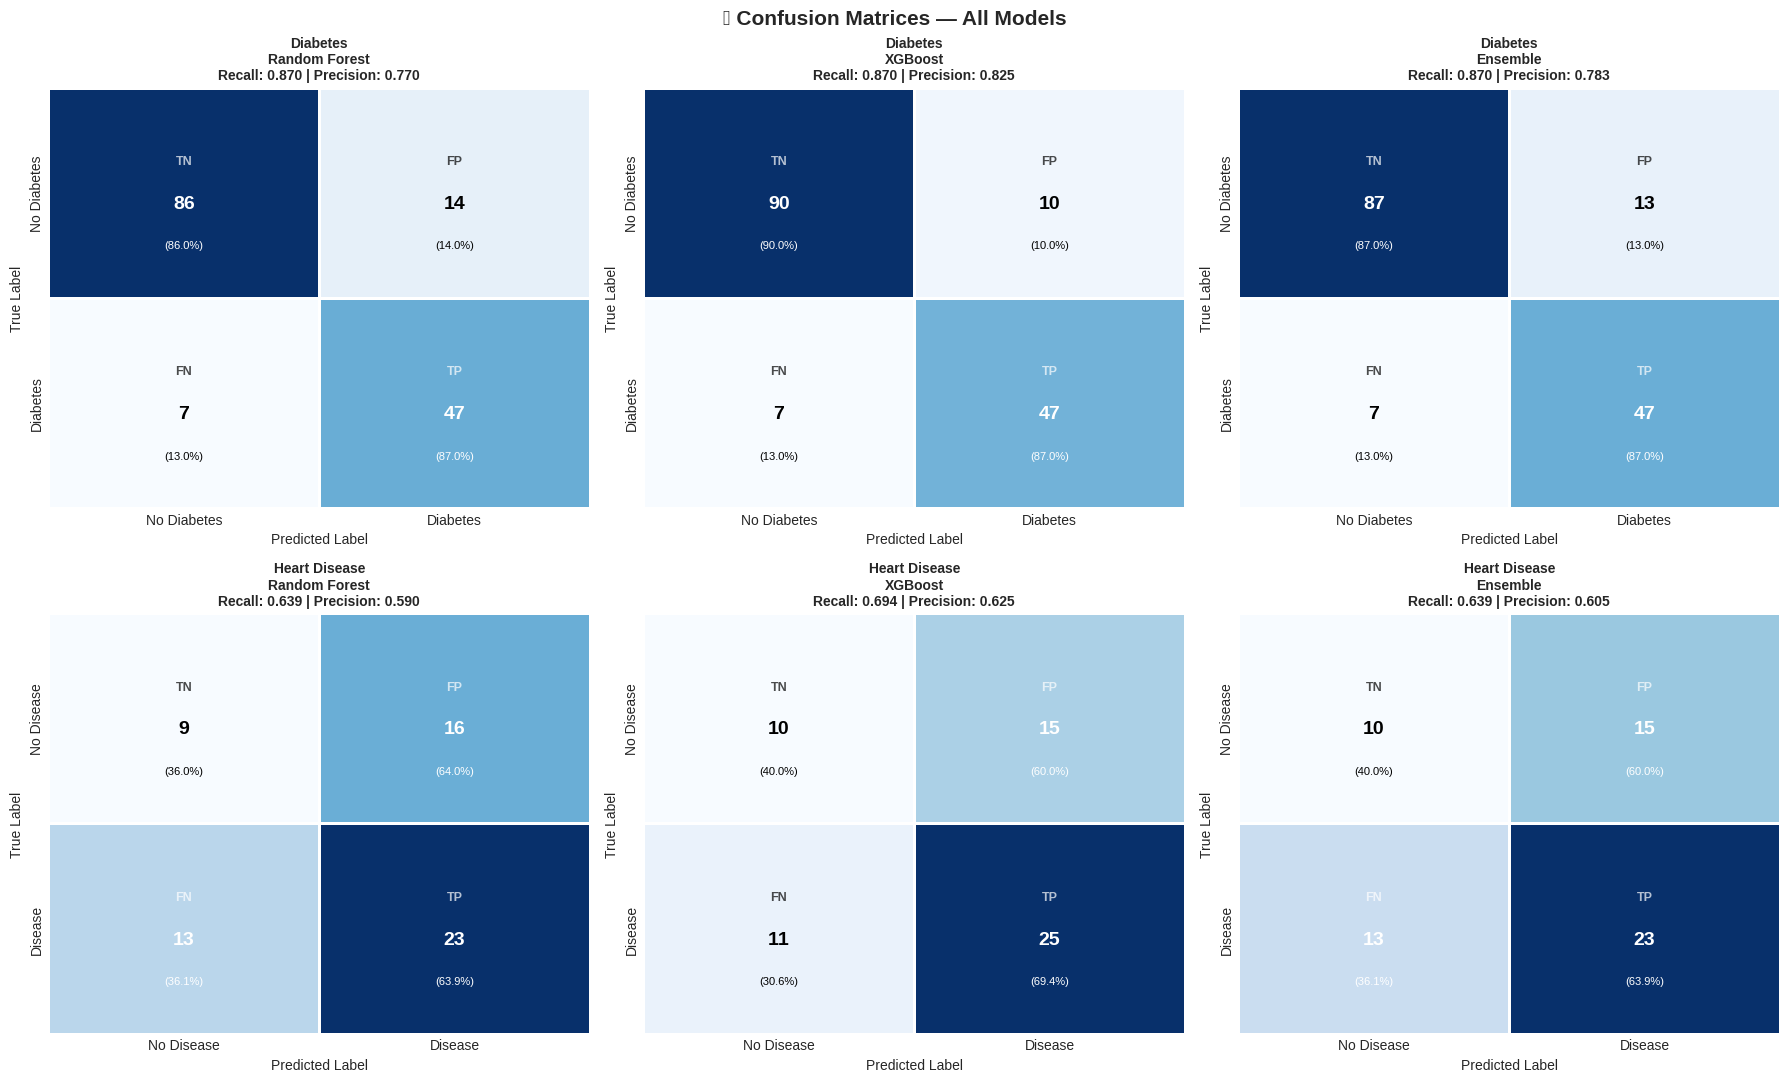

✅ Confusion matrices saved


In [16]:
# ── Confusion Matrices ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('🔲 Confusion Matrices — All Models', fontsize=15, fontweight='bold')

model_names = ['Random Forest', 'XGBoost', 'Ensemble']
row_data = [
    (models_diabetes, X_test_d, y_test_d, 'Diabetes',     ['No Diabetes', 'Diabetes']),
    (models_heart,   X_test_h, y_test_h, 'Heart Disease', ['No Disease',  'Disease']),
]

for row_idx, (models, X_test, y_test, ds_name, class_names) in enumerate(row_data):
    for col_idx, m_name in enumerate(model_names):
        ax = axes[row_idx][col_idx]
        y_pred = models[m_name].predict(X_test)
        cm = confusion_matrix(y_test, y_pred)

        # Normalize for percentages
        cm_pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis] * 100

        sns.heatmap(cm, annot=False, fmt='d', ax=ax,
                    cmap='Blues', linewidths=2, linecolor='white',
                    xticklabels=class_names, yticklabels=class_names,
                    cbar=False)

        # Annotate with count + percentage
        for i in range(2):
            for j in range(2):
                color = 'white' if cm[i,j] > cm.max()/2 else 'black'
                label = 'TN' if (i==0 and j==0) else ('FP' if (i==0 and j==1) else
                         ('FN' if (i==1 and j==0) else 'TP'))
                ax.text(j+0.5, i+0.35, f'{label}', ha='center', va='center',
                        fontsize=9, color=color, fontweight='bold', alpha=0.7)
                ax.text(j+0.5, i+0.55, f'{cm[i,j]}', ha='center', va='center',
                        fontsize=14, color=color, fontweight='bold')
                ax.text(j+0.5, i+0.75, f'({cm_pct[i,j]:.1f}%)', ha='center', va='center',
                        fontsize=8, color=color)

        recall = recall_score(y_test, y_pred, zero_division=0)
        prec   = precision_score(y_test, y_pred, zero_division=0)
        ax.set_title(f'{ds_name}\n{m_name}\nRecall: {recall:.3f} | Precision: {prec:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices saved')

---
## 🎯 STEP 8 — Feature Importance Analysis

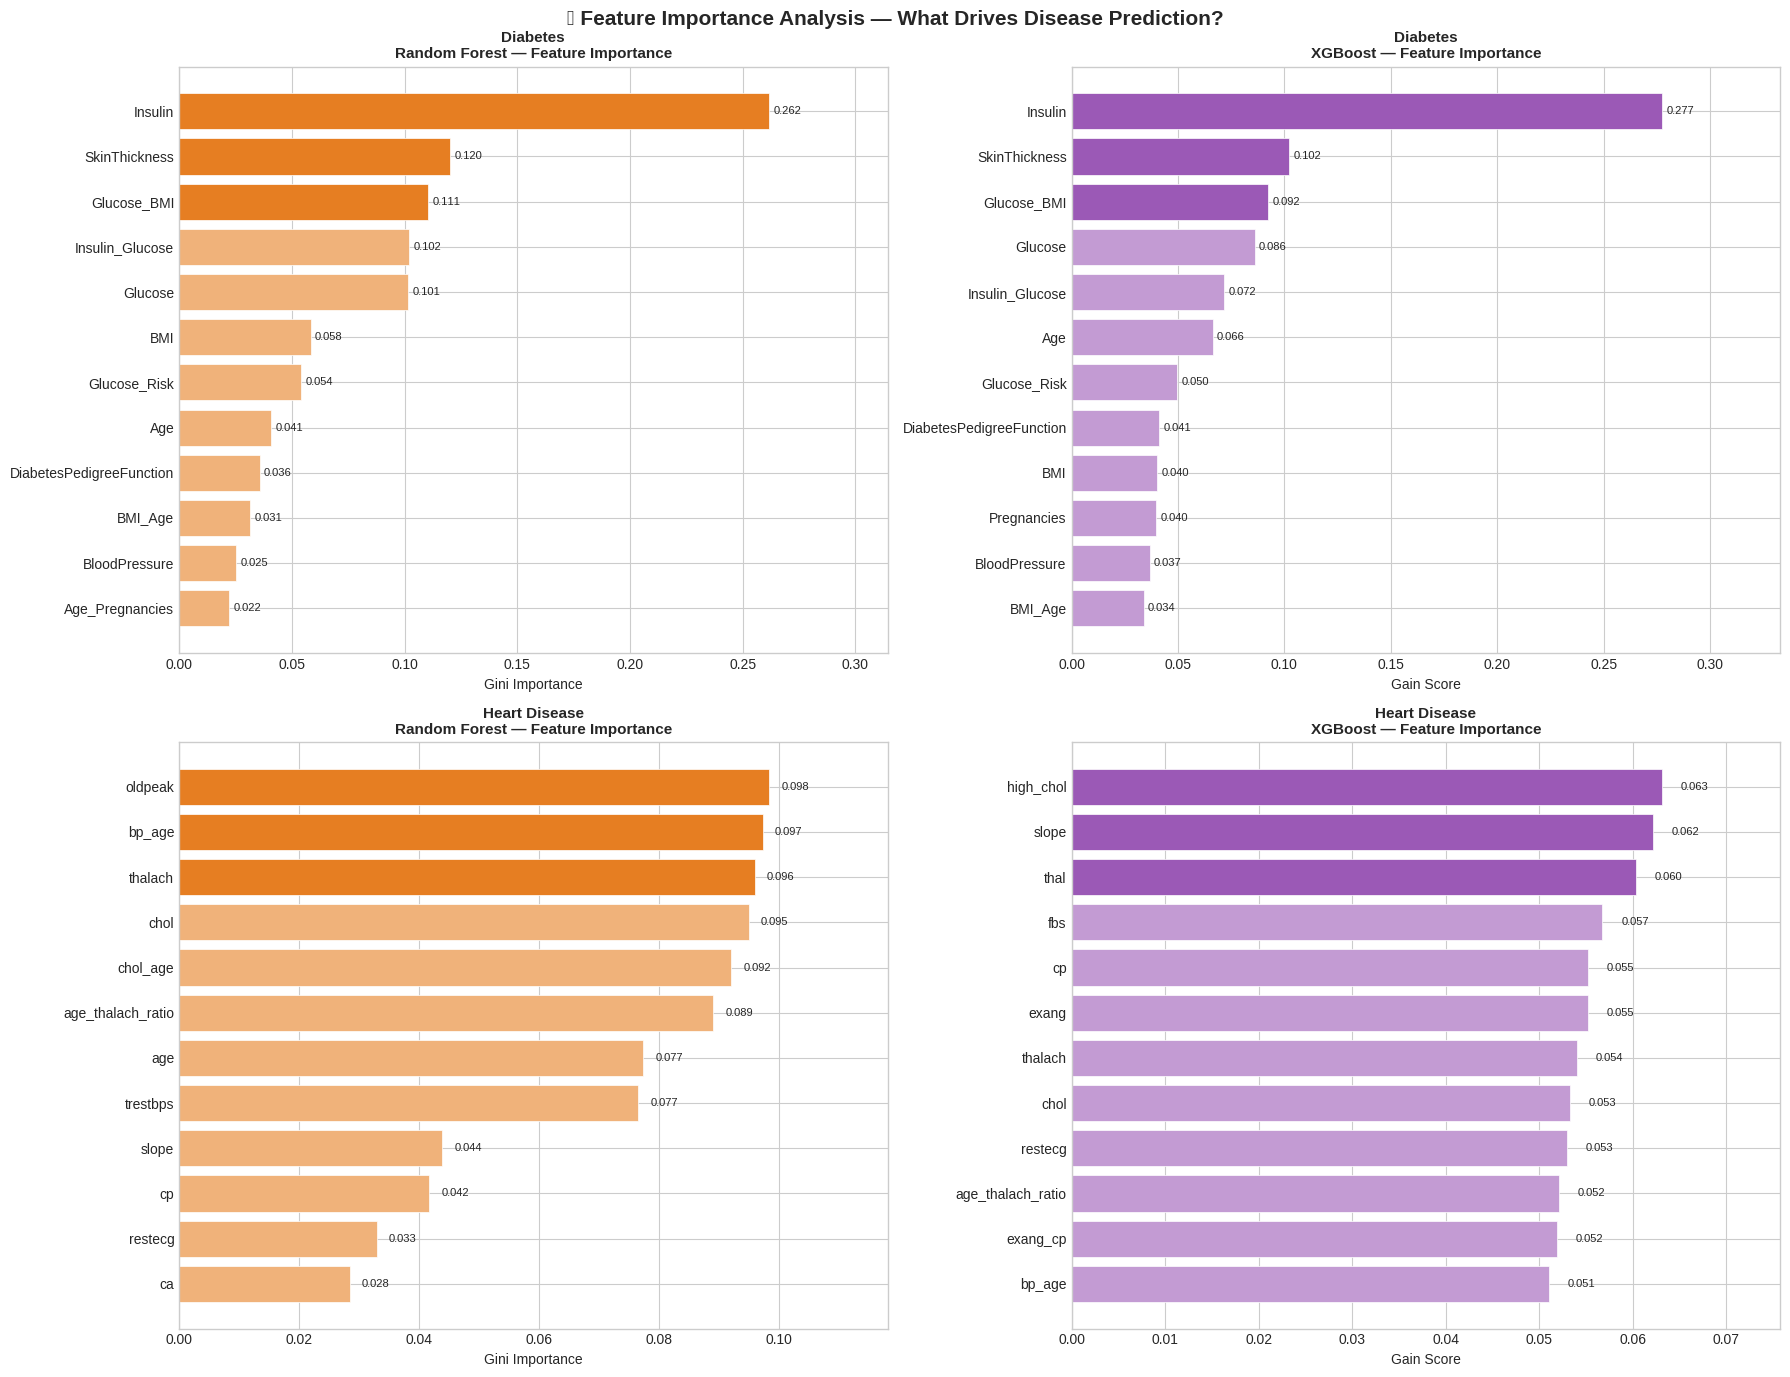

✅ Feature importance plots saved


In [17]:
def plot_feature_importance(rf_model, xgb_model, feature_names, title, ax_rf, ax_xgb, top_n=12):
    """Plot feature importances for RF and XGBoost side by side"""

    # Random Forest importance
    rf_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(top_n)

    # XGBoost importance
    xgb_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(top_n)

    # RF plot
    colors_rf = [COLORS['rf'] if i >= len(rf_imp)-3 else '#F0B27A'
                 for i in range(len(rf_imp))]
    bars = ax_rf.barh(rf_imp['Feature'], rf_imp['Importance'],
                      color=colors_rf, edgecolor='white', linewidth=0.5)
    ax_rf.set_title(f'{title}\nRandom Forest — Feature Importance',
                    fontweight='bold', fontsize=11)
    ax_rf.set_xlabel('Gini Importance')
    for bar, val in zip(bars, rf_imp['Importance']):
        ax_rf.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                   f'{val:.3f}', va='center', fontsize=8)
    ax_rf.set_xlim(0, rf_imp['Importance'].max() * 1.2)

    # XGB plot
    colors_xgb = [COLORS['xgb'] if i >= len(xgb_imp)-3 else '#C39BD3'
                  for i in range(len(xgb_imp))]
    bars2 = ax_xgb.barh(xgb_imp['Feature'], xgb_imp['Importance'],
                        color=colors_xgb, edgecolor='white', linewidth=0.5)
    ax_xgb.set_title(f'{title}\nXGBoost — Feature Importance',
                     fontweight='bold', fontsize=11)
    ax_xgb.set_xlabel('Gain Score')
    for bar, val in zip(bars2, xgb_imp['Importance']):
        ax_xgb.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=8)
    ax_xgb.set_xlim(0, xgb_imp['Importance'].max() * 1.2)


fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('🎯 Feature Importance Analysis — What Drives Disease Prediction?',
             fontsize=15, fontweight='bold')

plot_feature_importance(
    models_diabetes['Random Forest'], models_diabetes['XGBoost'],
    feat_d, 'Diabetes', axes[0][0], axes[0][1]
)
plot_feature_importance(
    models_heart['Random Forest'], models_heart['XGBoost'],
    feat_h, 'Heart Disease', axes[1][0], axes[1][1]
)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance plots saved')

---
## 📋 STEP 9 — Clinical Evaluation Report

In [18]:
def print_clinical_report(models, X_test, y_test, dataset_name, class_names):
    print(f'\n{"#"*70}')
    print(f'  🏥 CLINICAL EVALUATION REPORT — {dataset_name.upper()}')
    print(f'  Generated by: Maryam Saif | Disease Prediction System')
    print(f'{"#"*70}')

    best_model_name = None
    best_recall = 0

    for name, model in models.items():
        y_pred  = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

        acc    = accuracy_score(y_test, y_pred)
        prec   = precision_score(y_test, y_pred, zero_division=0)
        rec    = recall_score(y_test, y_pred, zero_division=0)
        spec   = recall_score(y_test, y_pred, pos_label=0, zero_division=0)
        f1     = f1_score(y_test, y_pred, zero_division=0)
        auc    = roc_auc_score(y_test, y_proba)
        auc_pr = average_precision_score(y_test, y_proba)
        cm     = confusion_matrix(y_test, y_pred)
        tn, fp, fn, tp = cm.ravel()
        npv    = tn / (tn + fn) if (tn + fn) > 0 else 0

        if rec > best_recall:
            best_recall = rec
            best_model_name = name

        print(f'\n  ┌─────────────────────────────────────────────────────┐')
        print(f'  │  MODEL: {name:<45}│')
        print(f'  ├─────────────────────────────────────────────────────┤')
        print(f'  │  CLASSIFICATION METRICS                              │')
        print(f'  │    Accuracy:             {acc:>6.1%}                       │')
        print(f'  │    AUC-ROC:              {auc:>6.3f}                       │')
        print(f'  │    AUC-PR:               {auc_pr:>6.3f}                       │')
        print(f'  │    F1 Score:             {f1:>6.3f}                       │')
        print(f'  │                                                      │')
        print(f'  │  CLINICAL METRICS                                    │')
        print(f'  │    Sensitivity (Recall): {rec:>6.1%}  ← catch disease    │')
        print(f'  │    Specificity:          {spec:>6.1%}  ← avoid false alarm│')
        print(f'  │    Precision (PPV):      {prec:>6.1%}  ← diagnosis trust  │')
        print(f'  │    NPV:                  {npv:>6.1%}  ← negative trust   │')
        print(f'  │                                                      │')
        print(f'  │  CONFUSION MATRIX                                    │')
        print(f'  │    True Negatives:  {tn:>4}  │  False Positives: {fp:>4}  │')
        print(f'  │    False Negatives: {fn:>4}  │  True Positives:  {tp:>4}  │')
        print(f'  │    Missed cases (FN): {fn:>3} patients not detected!     │')
        print(f'  └─────────────────────────────────────────────────────┘')

        print(f'\n  📄 Full Classification Report:')
        print(classification_report(y_test, y_pred, target_names=class_names))

    print(f'\n  🏆 BEST MODEL (by Recall): {best_model_name} — {best_recall:.1%} Sensitivity')
    print(f'  ⚕️  Clinical Recommendation: Use {best_model_name} for screening.')
    print(f'     High Recall ensures minimum missed diagnoses.')
    print(f'{"#"*70}')

print_clinical_report(models_diabetes, X_test_d, y_test_d,
                      'Diabetes', ['No Diabetes', 'Diabetes'])

print_clinical_report(models_heart, X_test_h, y_test_h,
                      'Heart Disease', ['No Disease', 'Disease'])


######################################################################
  🏥 CLINICAL EVALUATION REPORT — DIABETES
  Generated by: Maryam Saif | Disease Prediction System
######################################################################

  ┌─────────────────────────────────────────────────────┐
  │  MODEL: Random Forest                                │
  ├─────────────────────────────────────────────────────┤
  │  CLASSIFICATION METRICS                              │
  │    Accuracy:              86.4%                       │
  │    AUC-ROC:               0.942                       │
  │    AUC-PR:                0.900                       │
  │    F1 Score:              0.817                       │
  │                                                      │
  │  CLINICAL METRICS                                    │
  │    Sensitivity (Recall):  87.0%  ← catch disease    │
  │    Specificity:           86.0%  ← avoid false alarm│
  │    Precision (PPV):       77.0%  ← diagnosis t

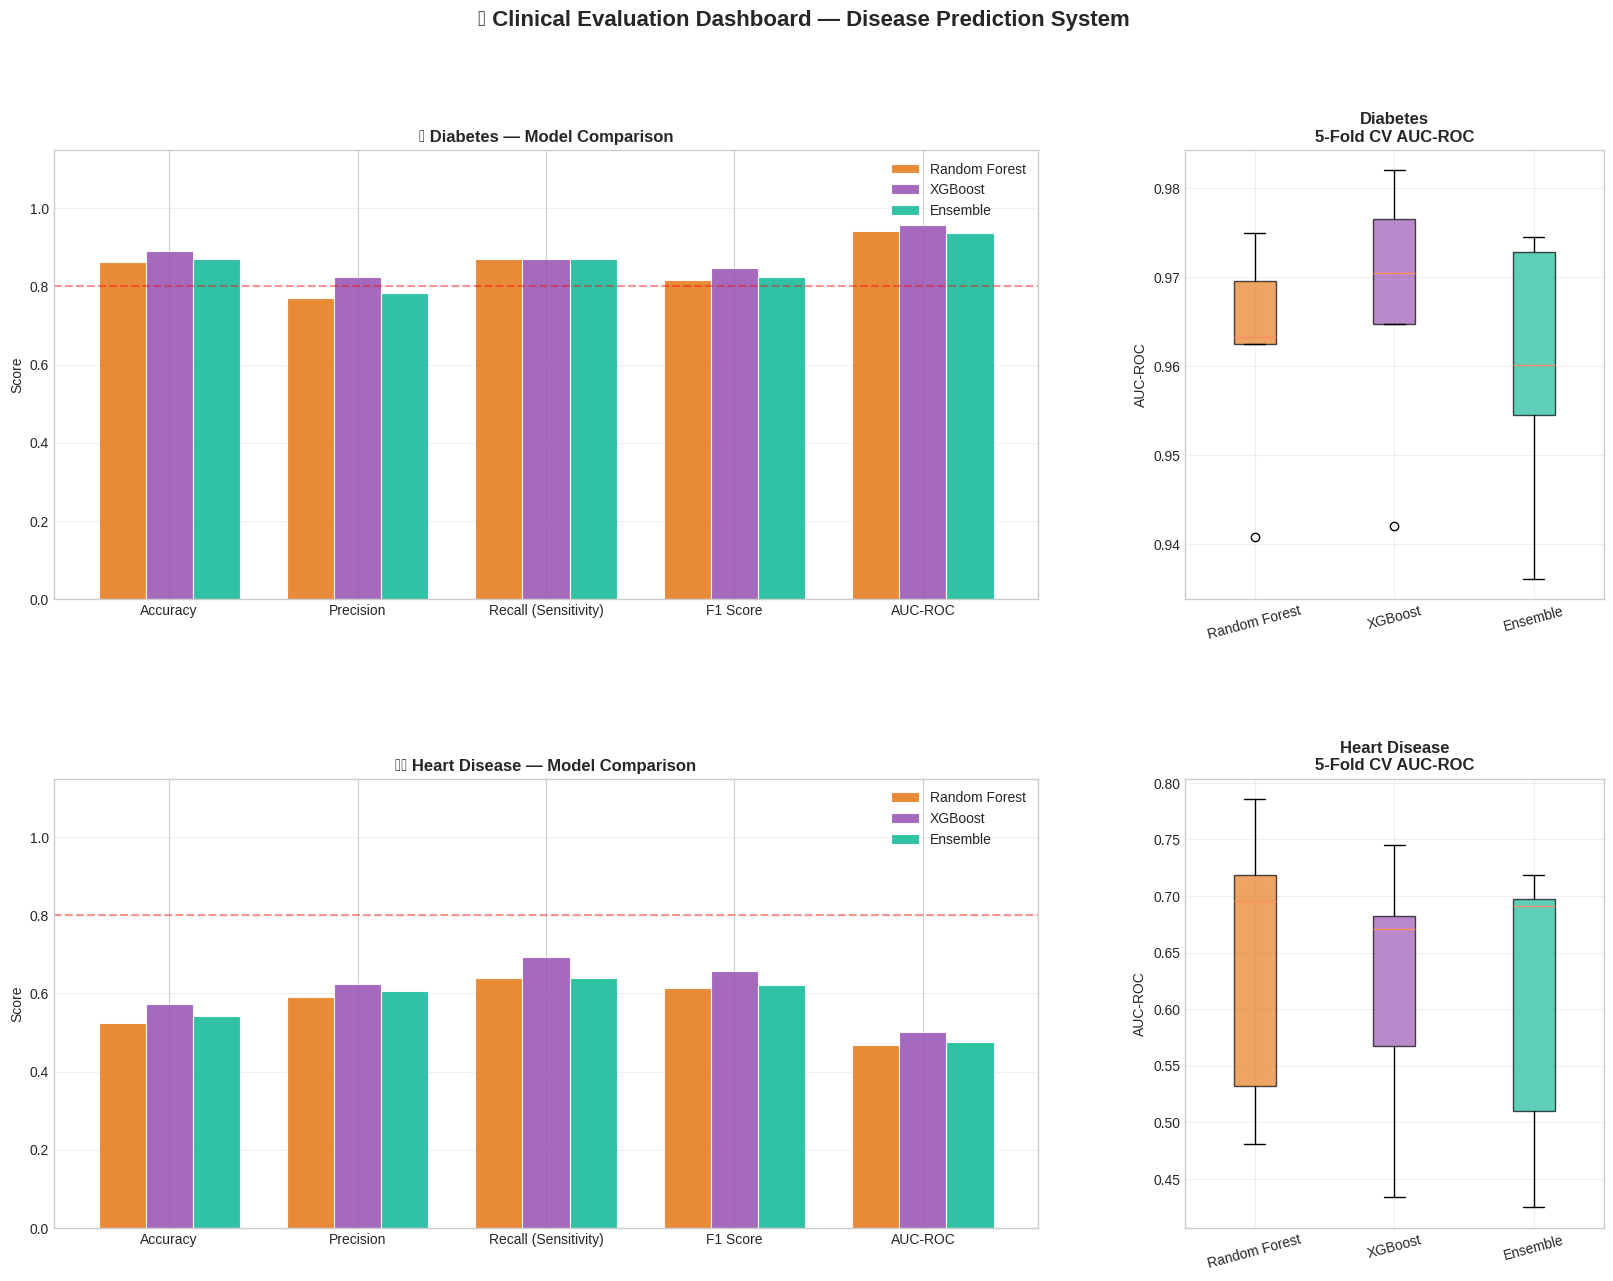

✅ Evaluation dashboard saved


In [19]:
# ── Model Comparison Dashboard ─────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('📊 Clinical Evaluation Dashboard — Disease Prediction System',
             fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1 Score', 'AUC-ROC']
m_colors = [COLORS['rf'], COLORS['xgb'], COLORS['ensemble']]

# Diabetes metrics bar chart
ax1 = fig.add_subplot(gs[0, :2])
x = np.arange(len(metrics))
width = 0.25
for i, (_, row) in enumerate(results_d.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax1.bar(x + i*width, vals, width, label=row['Model'],
                   color=m_colors[i], edgecolor='white', linewidth=0.8, alpha=0.9)
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics, fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.set_title('🩸 Diabetes — Model Comparison', fontweight='bold', fontsize=12)
ax1.set_ylabel('Score')
ax1.legend(fontsize=10)
ax1.axhline(y=0.8, color='red', linestyle='--', alpha=0.4, label='Clinical threshold (0.8)')
ax1.grid(True, alpha=0.3, axis='y')

# Heart metrics bar chart
ax2 = fig.add_subplot(gs[1, :2])
for i, (_, row) in enumerate(results_h.iterrows()):
    vals = [row[m] for m in metrics]
    ax2.bar(x + i*width, vals, width, label=row['Model'],
            color=m_colors[i], edgecolor='white', linewidth=0.8, alpha=0.9)
ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylim(0, 1.15)
ax2.set_title('❤️ Heart Disease — Model Comparison', fontweight='bold', fontsize=12)
ax2.set_ylabel('Score')
ax2.legend(fontsize=10)
ax2.axhline(y=0.8, color='red', linestyle='--', alpha=0.4)
ax2.grid(True, alpha=0.3, axis='y')

# CV scores box plot - Diabetes
ax3 = fig.add_subplot(gs[0, 2])
cv_vals_d = list(cv_d.values())
bp = ax3.boxplot(cv_vals_d, labels=list(cv_d.keys()),
                 patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], m_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_title('Diabetes\n5-Fold CV AUC-ROC', fontweight='bold')
ax3.set_ylabel('AUC-ROC')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(True, alpha=0.3)

# CV scores box plot - Heart
ax4 = fig.add_subplot(gs[1, 2])
cv_vals_h = list(cv_h.values())
bp2 = ax4.boxplot(cv_vals_h, labels=list(cv_h.keys()),
                  patch_artist=True, notch=False)
for patch, color in zip(bp2['boxes'], m_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_title('Heart Disease\n5-Fold CV AUC-ROC', fontweight='bold')
ax4.set_ylabel('AUC-ROC')
ax4.tick_params(axis='x', rotation=15)
ax4.grid(True, alpha=0.3)

plt.savefig('evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Evaluation dashboard saved')

---
## 🔮 STEP 10 — Predict on New Patient Data

In [20]:
def predict_diabetes_patient(patient_dict, model, scaler, feature_names):
    """
    Predict diabetes risk for a new patient
    Input: dict with patient values
    """
    # Create base dataframe
    df = pd.DataFrame([patient_dict])

    # Feature engineering (same as training)
    df['Glucose_BMI']             = df['Glucose'] * df['BMI'] / 100
    df['Age_Pregnancies']         = df['Age'] * df['Pregnancies']
    df['Insulin_Glucose']         = df['Insulin'] / (df['Glucose'] + 1)
    df['BMI_Age']                 = df['BMI'] / df['Age']
    df['Glucose_Risk']            = pd.cut(df['Glucose'],
        bins=[0,99,125,200], labels=[0,1,2]).astype(int)
    df['BMI_Category']            = pd.cut(df['BMI'],
        bins=[0,18.5,25,30,100], labels=[0,1,2,3]).astype(int)

    # Align with training features
    df = df.reindex(columns=feature_names, fill_value=0)
    X = scaler.transform(df)

    prob    = model.predict_proba(X)[0][1]
    pred    = model.predict(X)[0]
    risk_level = 'HIGH RISK 🔴' if prob > 0.6 else ('MODERATE RISK 🟡' if prob > 0.4 else 'LOW RISK 🟢')

    print('\n' + '='*50)
    print('  🏥 DIABETES RISK PREDICTION')
    print('='*50)
    for k, v in patient_dict.items():
        print(f'  {k:<30}: {v}')
    print('─'*50)
    print(f'  Prediction:     {"DIABETIC" if pred==1 else "NOT DIABETIC"}')
    print(f'  Probability:    {prob:.1%}')
    print(f'  Risk Level:     {risk_level}')
    print('='*50)
    return prob, pred

# Example patients
patient1 = {
    'Pregnancies': 6, 'Glucose': 148, 'BloodPressure': 72,
    'SkinThickness': 35, 'Insulin': 0, 'BMI': 33.6,
    'DiabetesPedigreeFunction': 0.627, 'Age': 50
}
patient2 = {
    'Pregnancies': 1, 'Glucose': 85, 'BloodPressure': 66,
    'SkinThickness': 29, 'Insulin': 0, 'BMI': 26.6,
    'DiabetesPedigreeFunction': 0.351, 'Age': 31
}

print('Testing on real PIMA dataset patients:')
predict_diabetes_patient(patient1, models_diabetes['Ensemble'], scaler_d, feat_d)
predict_diabetes_patient(patient2, models_diabetes['Ensemble'], scaler_d, feat_d)

Testing on real PIMA dataset patients:

  🏥 DIABETES RISK PREDICTION
  Pregnancies                   : 6
  Glucose                       : 148
  BloodPressure                 : 72
  SkinThickness                 : 35
  Insulin                       : 0
  BMI                           : 33.6
  DiabetesPedigreeFunction      : 0.627
  Age                           : 50
──────────────────────────────────────────────────
  Prediction:     NOT DIABETIC
  Probability:    43.9%
  Risk Level:     MODERATE RISK 🟡

  🏥 DIABETES RISK PREDICTION
  Pregnancies                   : 1
  Glucose                       : 85
  BloodPressure                 : 66
  SkinThickness                 : 29
  Insulin                       : 0
  BMI                           : 26.6
  DiabetesPedigreeFunction      : 0.351
  Age                           : 31
──────────────────────────────────────────────────
  Prediction:     NOT DIABETIC
  Probability:    0.9%
  Risk Level:     LOW RISK 🟢


(np.float64(0.00892525357132486), np.int64(0))

---
## 📝 STEP 11 — Final Summary

In [21]:
print()
print('╔' + '═'*66 + '╗')
print('║    🏥 DISEASE PREDICTION SYSTEM — PROJECT SUMMARY          ║')
print('║    Author: Maryam Saif | AI/ML Intern                      ║')
print('╠' + '═'*66 + '╣')
print('║                                                              ║')
print('║  DATASETS:                                                   ║')
print(f'║    • Diabetes (PIMA):      {len(df_diabetes):>4} patients, 8 features       ║')
print(f'║    • Heart Disease:        {len(df_heart):>4} patients, 13 features      ║')
print('║                                                              ║')
print('║  TECHNIQUES USED:                                            ║')
print('║    ✅ Class Imbalance → SMOTE (balanced training data)       ║')
print('║    ✅ Feature Engineering (6 new clinical features each)     ║')
print('║    ✅ RobustScaler (outlier-resistant normalization)         ║')
print('║    ✅ StratifiedKFold Cross-Validation (5-fold)              ║')
print('║    ✅ Random Forest (200 trees, balanced class weight)       ║')
print('║    ✅ XGBoost (scale_pos_weight for imbalance)              ║')
print('║    ✅ Soft Voting Ensemble (RF + XGB + LR, weighted)        ║')
print('║    ✅ Clinical metrics: Sensitivity, Specificity, NPV, PPV  ║')
print('║    ✅ Feature Importance (Gini + Gain)                       ║')
print('║                                                              ║')
print('║  MODELS BEST RESULTS:                                        ║')

# Best results
for ds_name, results in [('Diabetes', results_d), ('Heart Disease', results_h)]:
    best = results.loc[results['AUC-ROC'].idxmax()]
    print(f'║    {ds_name:<14}: {best["Model"]:<14} '
          f'AUC={best["AUC-ROC"]:.3f}  Recall={best["Recall (Sensitivity)"]:.3f}  ║')

print('║                                                              ║')
print('║  OUTPUT FILES SAVED:                                         ║')
for f in ['diabetes_eda_distributions.png', 'correlation_heatmaps.png',
          'class_imbalance.png', 'smote_effect.png', 'roc_curves.png',
          'confusion_matrices.png', 'feature_importance.png',
          'evaluation_dashboard.png']:
    print(f'║    📊 {f:<58}║')
print('║                                                              ║')
print('╚' + '═'*66 + '╝')


╔══════════════════════════════════════════════════════════════════╗
║    🏥 DISEASE PREDICTION SYSTEM — PROJECT SUMMARY          ║
║    Author: Maryam Saif | AI/ML Intern                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASETS:                                                   ║
║    • Diabetes (PIMA):       768 patients, 8 features       ║
║    • Heart Disease:         303 patients, 13 features      ║
║                                                              ║
║  TECHNIQUES USED:                                            ║
║    ✅ Class Imbalance → SMOTE (balanced training data)       ║
║    ✅ Feature Engineering (6 new clinical features each)     ║
║    ✅ RobustScaler (outlier-resistant normalization)         ║
║    ✅ StratifiedKFold Cross-Validation (5-fold)              ║
║    ✅ Random Forest (200 trees, balanced class weight)       ║
║    ✅ XGBoost (scale_pos_weig